<a href="https://colab.research.google.com/github/GhoffarFitassin/PCVK_Ganjil_2025/blob/main/PCVKWeek3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MODUL 3 – Operasi Citra Sederhana – Linier Brightness, Contrast, Inverse, Logarithmic Brightness, dan Grayscale Image

### D. PRAKTIKUM

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [81]:
import numpy as np
import cv2 as cv
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import glob
from math import log10, sqrt
from IPython.display import clear_output

### Transformasi Linier Brightness

 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 5


/tmp/ipython-input-3731976245.py:14: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original [y,x,c] + brightness, 0, 255)


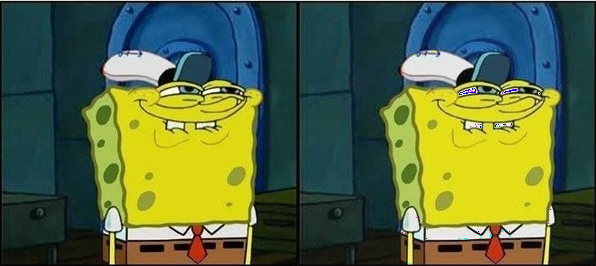

In [ ]:
print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')
try:
  brightness = int(input("Masukkan nilai kecerahan: "))
except ValueError:
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/Images/spongebob.jpg')
brightness_image = np.zeros(original.shape, original.dtype)
#akses per piksel
for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(original [y,x,c] + brightness, 0, 255)
#cara simple tanpa for loop
#brightness_image cv.convertScaleAbs (original, beta-brightness)
final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

## TUGAS PRAKTIKUM D1

1. Implementasikan inverse citra pada Google Colaboratory menggunakan formula yang terdapat pada bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut:

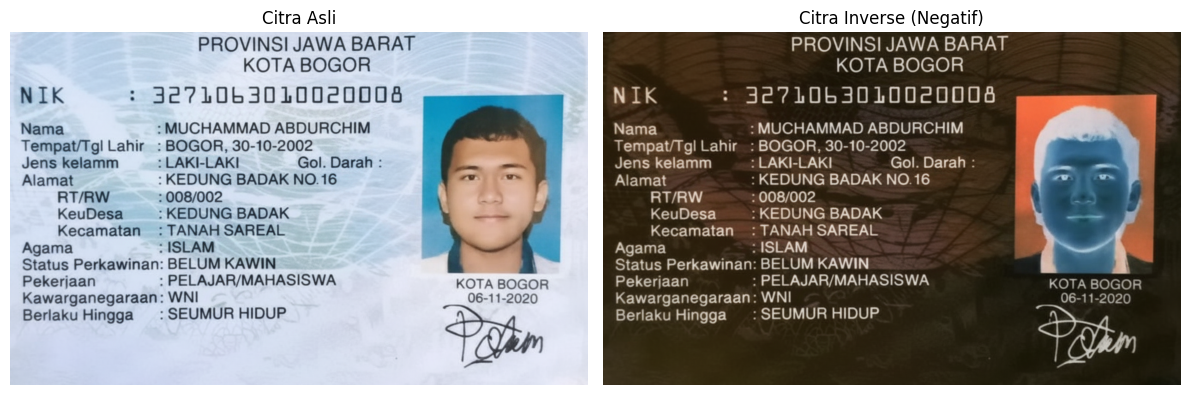

In [ ]:
img_rgb = cv.cvtColor(cv.imread('/content/drive/MyDrive/PCVK/Images/KTP_OHIM.png'), cv.COLOR_BGR2RGB)
inverted_img = 255 - img_rgb

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Citra Asli")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(inverted_img)
plt.title("Citra Inverse (Negatif)")
plt.axis("off")

plt.tight_layout()
plt.show()

2. Implementasikan transformasi contrast pada Google Colaboratory menggunakan
formula yang terdapat pada bagian Ulasan Teori untuk kontras, sehingga menghasilkan keluaran seperti berikut:

 Mengubah kontras dan tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 5
Masukkan nilai kontras: 5


/tmp/ipython-input-3515752368.py:17: RuntimeWarning: overflow encountered in scalar multiply
  kontras_image[y,x,c] = np.clip(kontras * original[y,x,c] + brightness_image[y,x,c], 0, 255)
/tmp/ipython-input-3515752368.py:17: RuntimeWarning: overflow encountered in scalar add
  kontras_image[y,x,c] = np.clip(kontras * original[y,x,c] + brightness_image[y,x,c], 0, 255)
/tmp/ipython-input-3515752368.py:16: RuntimeWarning: overflow encountered in scalar add
  brightness_image[y,x,c] = np.clip(original [y,x,c] + brightness, 0, 255)


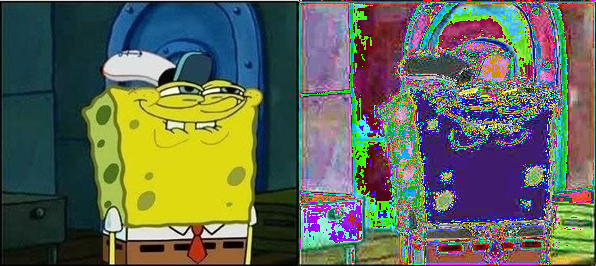

In [ ]:
print(' Mengubah kontras dan tingkat kecerahan citra ')
print('----------------------------------')
try:
  brightness = int(input("Masukkan nilai kecerahan: "))
  kontras = int(input("Masukkan nilai kontras: "))
except ValueError:
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/Images/spongebob.jpg')
brightness_image = np.zeros(original.shape, original.dtype)
kontras_image = np.zeros(original.shape, original.dtype)
#akses per piksel
for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(original [y,x,c] + brightness, 0, 255)
      kontras_image[y,x,c] = np.clip(kontras * original[y,x,c] + brightness_image[y,x,c], 0, 255)
#cara simple tanpa for loop
#brightness_image cv.convertScaleAbs (original, beta-brightness)
final_frame = cv.hconcat((original, kontras_image))
cv2_imshow(final_frame)

3. Implementasikan transformasi logarithmic brightness pada Google Colaboratory menggunakan formula yang terdapat pada bagian Ulasan Teori untuk transformasi log, sehingga menghasilkan keluaran seperti berikut:

 Mengubah tingkat kecerahan citra dengan logarithmic brightness 
-----------------------------------------------------------------
Masukkan tingkat kecerahan (+/-): 5


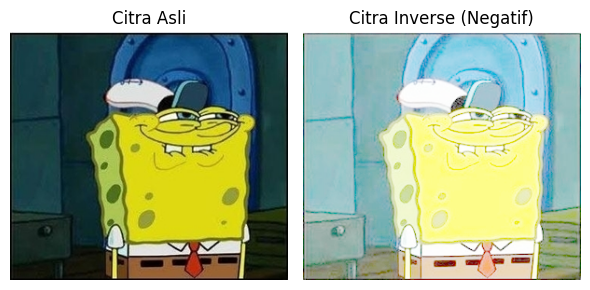

In [8]:
print(' Mengubah tingkat kecerahan citra dengan logarithmic brightness ')
print('-----------------------------------------------------------------')

# Pastikan path ke gambar benar
try:
    original = cv.cvtColor(cv.imread('/content/drive/MyDrive/PCVK/Images/spongebob.jpg'), cv.COLOR_BGR2RGB)
    if original is None:
        raise FileNotFoundError("Gambar tidak ditemukan. Pastikan path sudah benar.")

    brightness = int(input('Masukkan tingkat kecerahan (+/-): '))

except (FileNotFoundError, ValueError) as e:
    print(f"Error: {e}")
    exit()

# --- Transformasi Logaritmik ---
max_val = np.max(original)
c = 255 / np.log1p(max_val)
log_image = c * np.log1p(original.astype(np.float64))

# --- Tambahkan Faktor Kecerahan ---
final_image = log_image + brightness

# --- Normalisasi & Konversi Tipe Data ---
final_image = np.clip(final_image, 0, 255).astype(np.uint8)

# --- Tampilkan Hasil ---
plt.figure(figsize=(6, 6))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Citra Asli")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(final_image)
plt.title("Logarithmic brightness")
plt.axis("off")

plt.tight_layout()
plt.show()

4. Implementasikan transformasi grayscale menggunakan metode averaging, lightness, dan luminance pada Google Colaboratory menggunakan formula yang terdapat pada bagian Ulasan Teori, sehingga menghasilkan keluaran seperti berikut:

 a. Averaging

(np.float64(-0.5), np.float64(1132.5), np.float64(692.5), np.float64(-0.5))

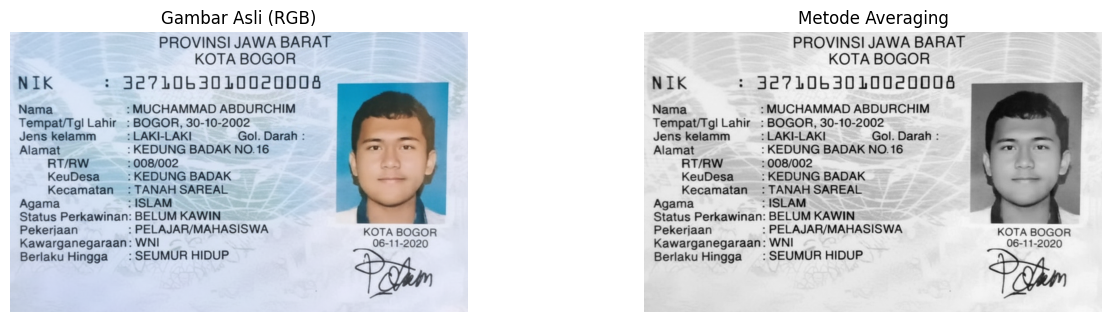

In [ ]:
original = cv.cvtColor(cv.imread('/content/drive/MyDrive/PCVK/Images/KTP_OHIM.png'), cv.COLOR_BGR2RGB)
gs_avg = np.zeros(original.shape[:2], dtype=np.uint8)
gs_avg = np.mean(original, axis=2).astype(np.uint8)

for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    gs_avg[y,x] = np.mean(original[y,x])

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(original)
plt.title("Gambar Asli (RGB)")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(gs_avg, cmap='gray')
plt.title("Metode Averaging")
plt.axis("off")

b. lightness

(np.float64(-0.5), np.float64(1132.5), np.float64(692.5), np.float64(-0.5))

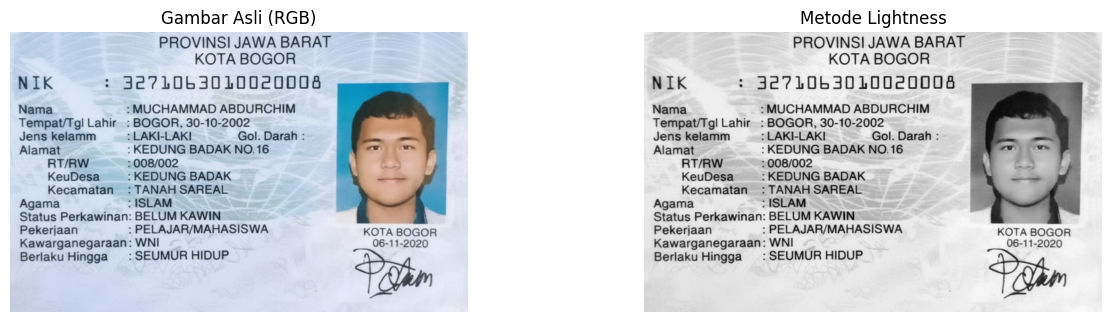

In [ ]:
original = cv.cvtColor(cv.imread('/content/drive/MyDrive/PCVK/Images/KTP_OHIM.png'), cv.COLOR_BGR2RGB)
img_float = original.astype(np.float32) # Konversi ke float untuk perhitungan
min_val = cv.min(cv.min(img_float[:,:,0], img_float[:,:,1]), img_float[:,:,2])
max_val = cv.max(cv.max(img_float[:,:,0], img_float[:,:,1]), img_float[:,:,2])
# min_val = np.min(original, axis=2)
# max_val = np.max(original, axis=2)
gs_ln_float = (min_val + max_val) / 2
gs_ln = gs_ln_float.astype(np.uint8)

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(original)
plt.title("Gambar Asli (RGB)")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(gs_ln, cmap='gray')
plt.title("Metode Lightness")
plt.axis("off")

c. luminance

(np.float64(-0.5), np.float64(1132.5), np.float64(692.5), np.float64(-0.5))

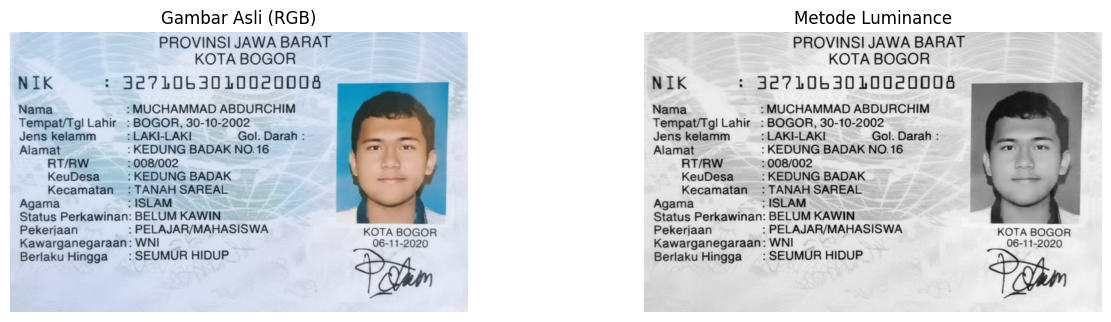

In [ ]:
original = cv.cvtColor(cv.imread('/content/drive/MyDrive/PCVK/Images/KTP_OHIM.png'), cv.COLOR_BGR2RGB)
gs_lm = np.zeros(original.shape[:2], dtype=np.uint8)
R, G, B = original[:, :, 0], original[:, :, 1], original[:, :, 2]
gs_lm = np.array(0.2126 * R + 0.7152 * G + 0.0722 * B, dtype=np.uint8)

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(original)
plt.title("Gambar Asli (RGB)")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(gs_lm, cmap='gray')
plt.title("Metode Luminance")
plt.axis("off")

5. Tampilkanlah warna tertentu pada citra, dan ubah warna lain menjadi grayscale. Misal, tampilkan warna biru pada citra masukan dan ubah bagian lain yang tidak berwarna biru menjadi grayscale seperti pada contoh berikut:

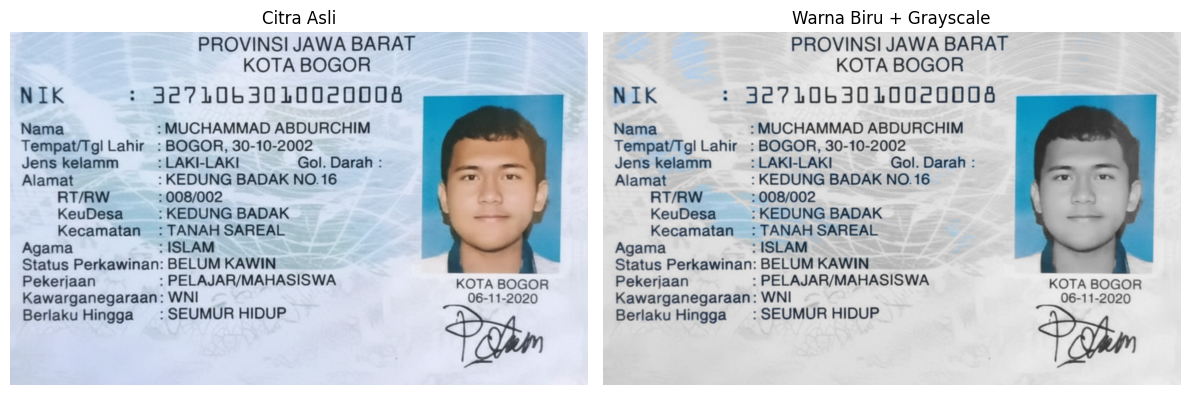

In [23]:
original = cv.imread('/content/drive/MyDrive/PCVK/Images/KTP_OHIM.png')

original_gs = cv.cvtColor(original, cv.COLOR_BGR2GRAY)
original_3ch = cv.cvtColor(original_gs, cv.COLOR_GRAY2BGR)

hsv_img = cv.cvtColor(original, cv.COLOR_BGR2HSV)
blue_lower = np.array([90, 50, 50])
blue_upper = np.array([130, 255, 255])
blue_mask = cv.inRange(hsv_img, blue_lower, blue_upper)

blue_part = cv.bitwise_and(original, original, mask=blue_mask)
non_blue_mask = cv.bitwise_not(blue_mask)
non_blue_part = cv.bitwise_and(original_3ch, original_3ch, mask=non_blue_mask)
final_image = cv.bitwise_or(blue_part, non_blue_part)

original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
final_image_rgb = cv.cvtColor(final_image, cv.COLOR_BGR2RGB)

# Atur ukuran figure
plt.figure(figsize=(12, 6))

# Tampilkan gambar asli
plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title("Citra Asli")
plt.axis("off")

# Tampilkan gambar yang sudah dimodifikasi
plt.subplot(1, 2, 2)
plt.imshow(final_image_rgb)
plt.title("Warna Biru + Grayscale")
plt.axis("off")

# Atur layout agar rapi
plt.tight_layout()
plt.show()

## D2. Operasi Aritmatika dan Logika

1. Buat Gamma Correction sesuai dengan petunjuk berikut

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 5


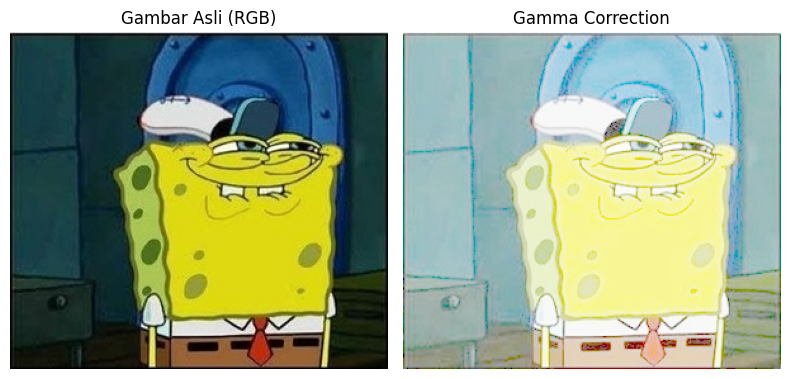

In [20]:
print(' Gamma Correction pada citra ')
print('----------------------------------')

try:
    # Gamma Correction umumnya menggunakan nilai float
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, input bukan angka.')
    exit()

original = cv.cvtColor(cv.imread('/content/drive/MyDrive/PCVK/Images/spongebob.jpg'), cv.COLOR_BGR2RGB)

# Konversi gambar ke tipe data float untuk perhitungan
original_float = original.astype(np.float64)

# Lakukan normalisasi
normalized_img = original_float / 255.0

# Terapkan rumus gamma correction
gamma_corrected_img = np.power(normalized_img, 1/gamma)

# Kembalikan ke rentang 0-255 dan ubah ke tipe data uint8
gamma_corrected_img = np.clip(gamma_corrected_img * 255, 0, 255).astype(np.uint8)

# --- Tampilkan Gambar ---
# Gabungkan citra asli dan hasil gamma correction untuk perbandingan
plt.figure(figsize=(8, 8))

plt.subplot(2, 2, 1)
plt.imshow(original)
plt.title("Gambar Asli (RGB)")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(gamma_corrected_img)
plt.title("Gamma Correction")
plt.axis("off")

plt.tight_layout()
plt.show()

2. Buat Simulasi Image Depth

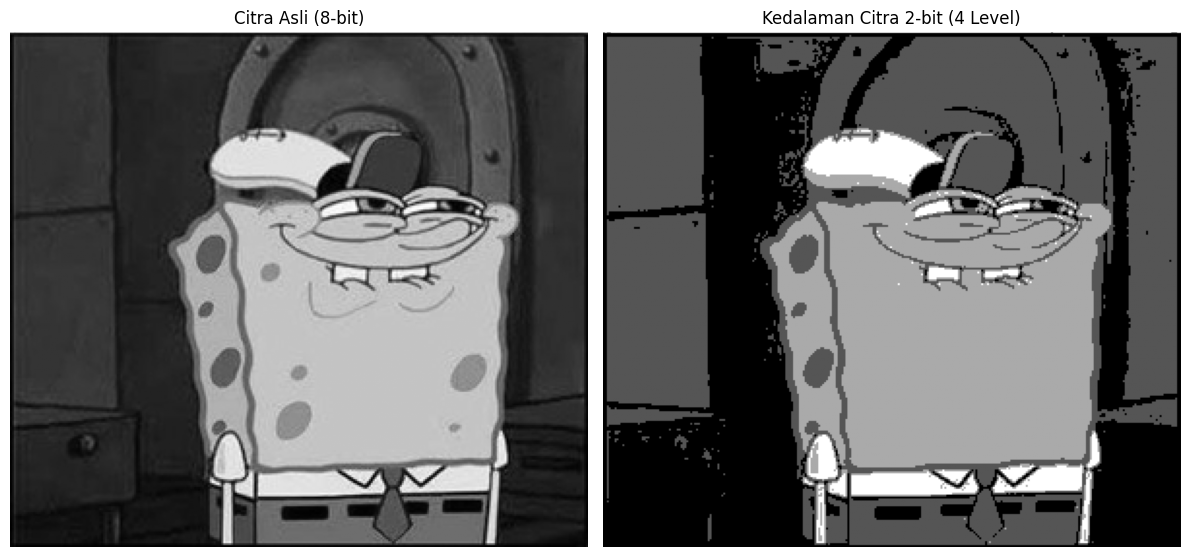

In [31]:
bit_depth=2
original = cv.imread('/content/drive/MyDrive/PCVK/Images/spongebob.jpg', cv.IMREAD_GRAYSCALE)
# --- Implementasi Perubahan Kedalaman Citra ---
# 1. Kuantisasi nilai piksel
# Gunakan np.round untuk membulatkan nilai ke level terdekat
quantized_img = np.round(original / level)

# 2. Reskalasi nilai piksel
# Kembalikan nilai ke rentang 0-255
depth_img = np.clip(quantized_img * level, 0, 255).astype(np.uint8)

# --- Menampilkan Gambar dengan Matplotlib ---
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original, cmap="gray")
plt.title('Citra Asli (8-bit)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(depth_img, cmap="gray")
plt.title(f'Kedalaman Citra {bit_depth}-bit ({2**bit_depth} Level)')
plt.axis('off')

plt.tight_layout()
plt.show()

3. Buat modul Average Denoising

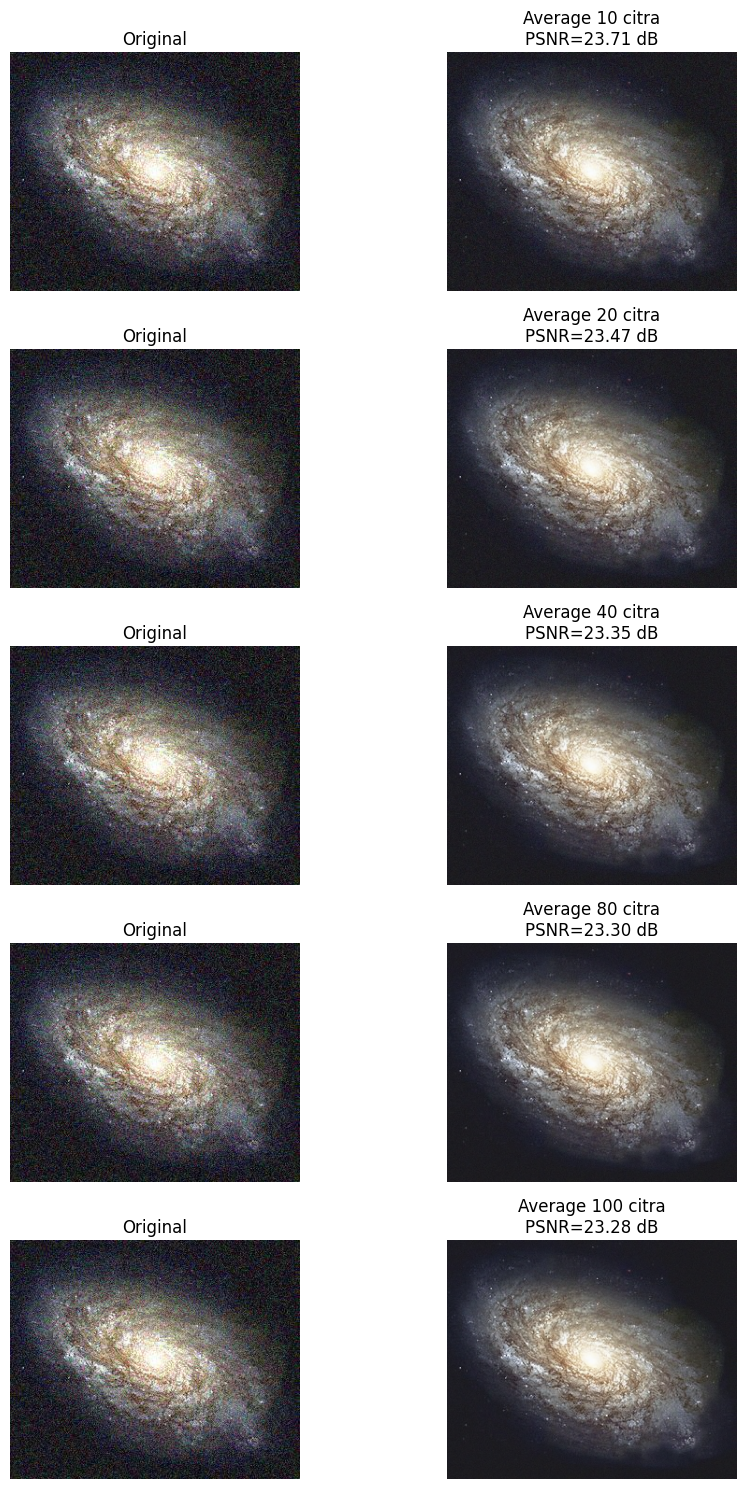


Hasil PSNR (dB):
----------------
10 citra : 23.71 dB
20 citra : 23.47 dB
40 citra : 23.35 dB
80 citra : 23.30 dB
100 citra : 23.28 dB


In [45]:
# ----------------- Fungsi Hitung PSNR -----------------
def hitung_psnr(img1, img2):
    # Pastikan citra memiliki dimensi yang sama
    if img1.shape != img2.shape:
        raise ValueError("Dimensi citra tidak cocok.")

    # Konversi ke float32 untuk perhitungan
    mse = np.mean((img1.astype(np.float32) - img2.astype(np.float32)) ** 2)

    # PSNR tak terbatas jika MSE nol (citra identik)
    if mse == 0:
        return float('inf')

    # Hitung PSNR
    return 20 * log10(255.0 / sqrt(mse))

# ----------------- Fungsi Average Denoising -----------------
def average_denoising(original_path, noise_folder, jumlah_list, tampilkan=True):
    # Baca citra original
    original = cv.imread(original_path)
    if original is None:
        print(f"Error: Tidak dapat memuat citra original dari path: {original_path}")
        return None

    original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

    # Baca semua citra noise
    cv_img = []
    # Menggunakan wildcard untuk memuat semua file jpg
    for img_path in glob.glob(noise_folder + "/*.jpg"):
        n = cv.imread(img_path)
        if n is not None:
            # Mengonversi langsung ke RGB agar konsisten dengan Matplotlib
            cv_img.append(cv.cvtColor(n, cv.COLOR_BGR2RGB))
        else:
            print(f"Peringatan: Tidak dapat memuat citra noise dari path: {img_path}")

    if not cv_img:
        print(f"Error: Tidak ada citra noise yang berhasil dimuat dari folder: {noise_folder}")
        return None

    # Simpan hasil
    results = {}
    for jumlah in jumlah_list:
        if jumlah > len(cv_img):
            print(f"Peringatan: Jumlah citra yang diminta ({jumlah}) melebihi total gambar yang tersedia ({len(cv_img)}).")
            continue

        # Gunakan np.mean untuk rata-rata yang efisien
        avg_img = np.mean(cv_img[:jumlah], axis=0).astype(np.uint8)
        psnr_val = hitung_psnr(original_rgb, avg_img)
        results[jumlah] = (avg_img, psnr_val)

    # Tampilkan hasil jika diminta
    if tampilkan:
        # Menyiapkan figure dengan layout 5 baris, 2 kolom
        rows, cols = 5, 2
        plt.figure(figsize=(10, 15))
        plot_index = 1

        for jumlah, (avg_img, psnr_val) in results.items():
            # Subplot untuk gambar original
            plt.subplot(rows, cols, plot_index)
            plt.imshow(original_rgb)
            plt.title("Original")
            plt.axis("off")

            # Subplot untuk gambar hasil average
            plt.subplot(rows, cols, plot_index + 1)
            plt.imshow(avg_img)
            plt.title(f"Average {jumlah} citra\nPSNR={psnr_val:.2f} dB")
            plt.axis("off")

            plot_index += 2

        plt.tight_layout()
        plt.show()

    return results

# ----------------- Pemanggilan Utama -----------------
# Bersihkan output lama setiap kali cell dijalankan
clear_output(wait=True)

# Path citra dan folder noise
# Sesuaikan dengan lokasi file Anda di Google Drive
original_path = "/content/drive/MyDrive/PCVK/Images/galaxy_original.jpg" # Asumsi ada versi original tanpa noise
noise_folder = "/content/drive/MyDrive/PCVK/Images/noises" # Folder berisi citra bernoise

# Daftar jumlah citra yang akan di-average
jumlah_list = [10, 20, 40, 80, 100]

# Jalankan average denoising
results = average_denoising(original_path, noise_folder, jumlah_list)

# Cetak nilai PSNR
if results:
    print("\nHasil PSNR (dB):")
    print("----------------")
    for jumlah, (_, psnr_val) in results.items():
        print(f"{jumlah} citra : {psnr_val:.2f} dB")

4. Buat image masking

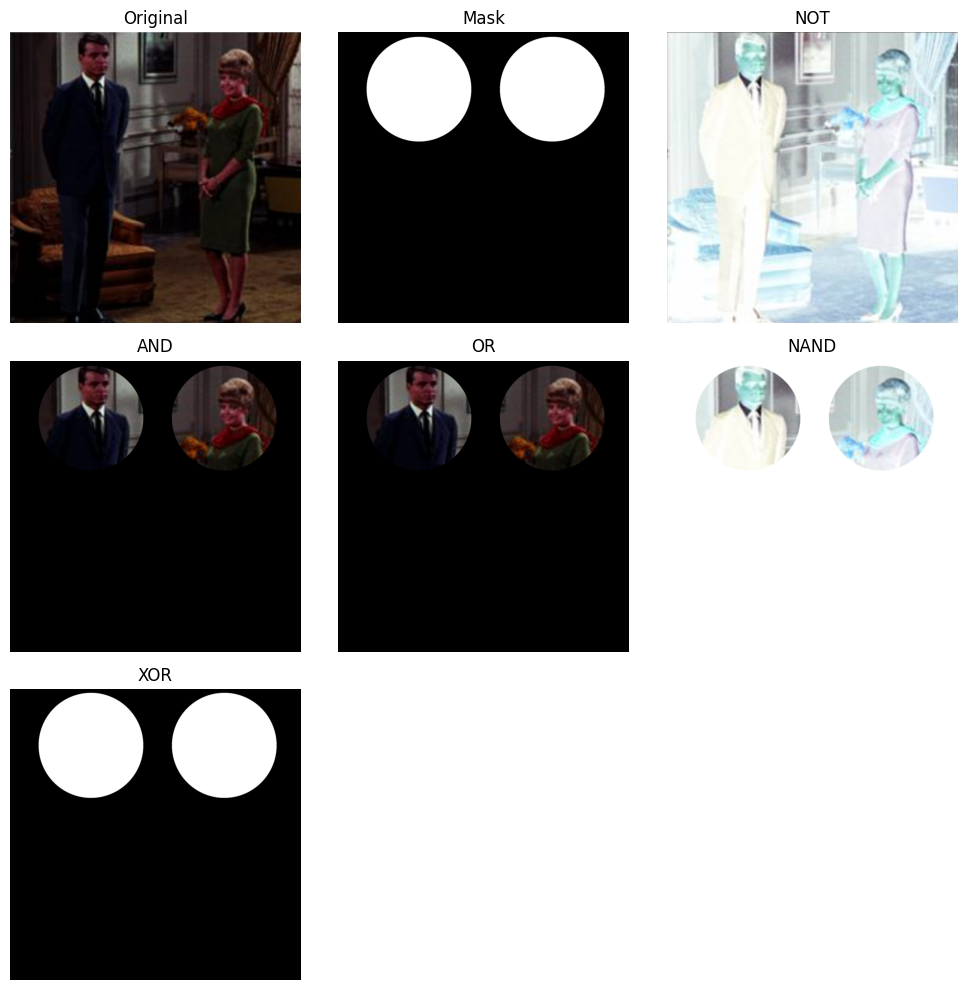

In [94]:
original = cv.cvtColor(cv.imread('/content/drive/MyDrive/PCVK/Images/people.png'), cv.COLOR_BGR2RGB)

# --- Membuat circle mask ---
mask = np.zeros(original.shape[:2], dtype="uint8")
cv.circle(mask, (850, 600), 550, 255, -1)
cv.circle(mask, (2250, 600), 550, 255, -1)

# --- Implementasi Operasi Logika ---
not_img = cv.bitwise_not(original)
and_img = cv.bitwise_and(original, original, mask=mask)
or_img = cv.bitwise_or(original, original, mask=mask)
nand_img = cv.bitwise_not(and_img)
xor_img = cv.bitwise_xor(original, not_img, mask=mask)

# --- Menampilkan Hasil dengan Matplotlib ---
# Daftar gambar dan judulnya
titles = ["Original", "Mask", "NOT", "AND", "OR", "NAND", "XOR"]
images = [original, mask, not_img, and_img, or_img, nand_img, xor_img]

plt.figure(figsize=(10, 10))

for i in range(len(images)):
    plt.subplot(3, 3, i + 1)
    display_img = images[i]

    plt.imshow(display_img, cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()